This notebook demonstrates how to use the EMCellFiner model for super-resolution reconstruction of electron microscopy (EM) images, and reproduces the results presented in the EMCFsys paper.

#### How to use EMCellFiner to make the low resolution EM images to high resolution EM images

In [ ]:
import numpy as np 
import torch
from PIL import Image
import matplotlib.pyplot as plt

from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.img_utils import tensor2img
# When it is new kernel, you need to run the following code to set the root path, otherwise it will report an error that the module cannot be found.
#------------------- Set the root path-------------------------
from mmengine import Config
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))
#-----------------------------------------------------
# 1. init the model
# set the tile_size according to your GPU memory, 512 is recommended for 8GB GPU
# scale can be set to 2 or 4, depending on your needs, and 4 is recommended for better performance.
model = HATModel(scale=4, tile_size=512) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# 2. read the image
img_path = str(BASE_DIR / "tests" / "test_img.tif")
# support RGB and grayscale images, and resize to 512x512 for speed up inference, 
# you can remove the resize operation if you want to keep the original size.
img = Image.open(img_path).convert("RGB").resize((512, 512), resample=Image.BICUBIC)

# convert to tensor and normalize to [0, 1]
img_np = np.array(img).astype(np.float32) / 255.
# convert Tensor: (H, W, C) -> (C, H, W) -> (1, C, H, W)
img_torch = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)
print(f"Input Shape: {img_torch.shape}")
# 3. inference

import time
start_time = time.time()
with torch.no_grad():
    output = model(img_torch) 
end_time = time.time()
print(f"Inference Time: {end_time - start_time:.2f} seconds")
print(f"Output Shape: {output.shape}")

# 4. post-process the output tensor
output = output.cpu()
img_out = tensor2img(output, rgb2bgr=False, min_max=(0, 1))
# 5. convert to PIL Image
img_final = Image.fromarray(img_out)

# 5. show and save the image
# img_final.show() 
img_final.save("result_sr.png")
print("Done.")

In [ ]:
# There also be a inference api for numpy array, which is more convenient for some users. 
# You can use the following code to inference with numpy array.
from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy
# 1. Set the model and tile_size according to your GPU memory, 512 is recommended for 8GB GPU
model = HATModel(scale=4, tile_size=512)
# 2. load the image and convert to numpy array
img_path = str(BASE_DIR / "tests" / "test_img.tif")
img = Image.open(img_path).convert("RGB").resize((512, 512), resample=Image.BICUBIC)
img_np = np.array(img)
# 3. Inference with numpy array
img_out = hat_infer_numpy(model, img_np, device=device)
# 4. Get the output image, which is a numpy array with shape (H, W, C) and dtype uint8
img_final = Image.fromarray(img_out)

# 5. show and save the image
img_final.show() 
img_final.save("result_sr.png")
print("Done.")

# Reproducibility of the paper

## Figure2-c

In [ ]:
# When it is new kernel, you need to run the following code to set the root path, otherwise it will report an error that the module cannot be found.
#------------------- Set the root path-------------------------
from mmengine import Config
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))
#-------------- Zeyu0102/EMCFsys_SuperResolution_Reproduction_Dataset
import os
from huggingface_hub import snapshot_download
local_dir = str(BASE_DIR / "demo" /"datasets_temp" / "EMCFsys_SuperResolution_Reproduction_Dataset")

# save the dataset to local_dir, and set resume_download=True to resume the download if it was interrupted
snapshot_download(repo_id="Zeyu0102/EMCFsys_SuperResolution_Reproduction_Dataset", 
                  repo_type="dataset",
                  local_dir=local_dir,
                  local_dir_use_symlinks=False, 
                  resume_download=True)


In [ ]:
# iterate all images and get SR results 
LR_dir = os.path.join(local_dir, "SR_Fig2C", "LR")
SR_dir = os.path.join(local_dir, "SR_Fig2C", "SR")
if not os.path.exists(SR_dir):
    os.makedirs(SR_dir)
    
from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy
import torch
from PIL import Image
import numpy as np

model = HATModel(scale=4, tile_size=512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for img_name in os.listdir(LR_dir):
    if img_name.lower().endswith(('.png')):
        img_path = os.path.join(LR_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        img_out = hat_infer_numpy(model, img_np, device=device)
        img_final = Image.fromarray(img_out)
        # save the result image
        result_path = os.path.join(SR_dir, img_name)
        img_final.save(result_path)
        print(f"Done: {result_path}")

## Fig2_f and supFig8

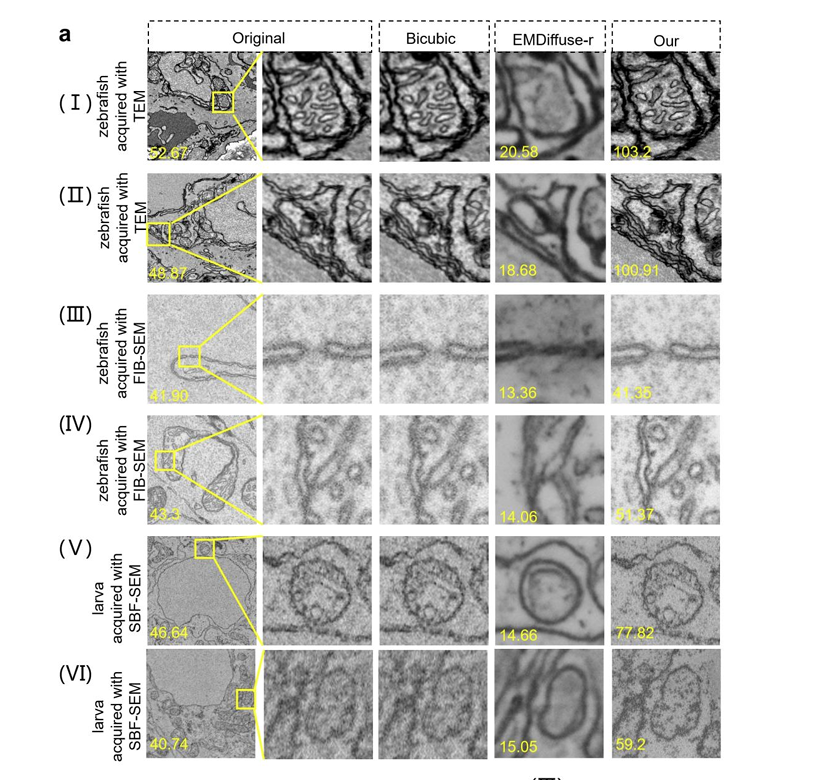

In [ ]:
# When it is new kernel, you need to run the following code to 
# set the root path, otherwise it will report an error that the module cannot be found.
#------------------- Set the root path-------------------------
from mmengine import Config
import pathlib
import sys
# Get the base directory of the project, which is the parent directory of the current working directory
BASE_DIR = pathlib.Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")
# set the root directory of the project to the module search path
root = pathlib.Path(BASE_DIR)
# add the root directory to the module search path
sys.path.insert(0, str(root))
#-----------------------------------------------------
import os
from huggingface_hub import snapshot_download
local_dir = str(BASE_DIR / "demo" / "datasets_temp" / "EMCFsys_SuperResolution_Reproduction_Dataset")


# iterate all images and get SR results 
GT_dir = os.path.join(local_dir, "SR_Fig2F_supFig8", "GT")
SR_dir = os.path.join(local_dir, "SR_Fig2F_supFig8", "SR")
if not os.path.exists(SR_dir):
    os.makedirs(SR_dir)
    
from src.emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from src.emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy
import torch
from PIL import Image
import numpy as np

model = HATModel(scale=4, tile_size=512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for img_name in os.listdir(GT_dir):
    if img_name.lower().endswith(('.tif')):
        img_path = os.path.join(GT_dir, img_name)
        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        img_out = hat_infer_numpy(model, img_np, device=device)
        img_final = Image.fromarray(img_out)
        # save the result image
        result_path = os.path.join(SR_dir, img_name)
        img_final.save(result_path)
        print(f"Done: {result_path}")

Show the image of Fig2 F

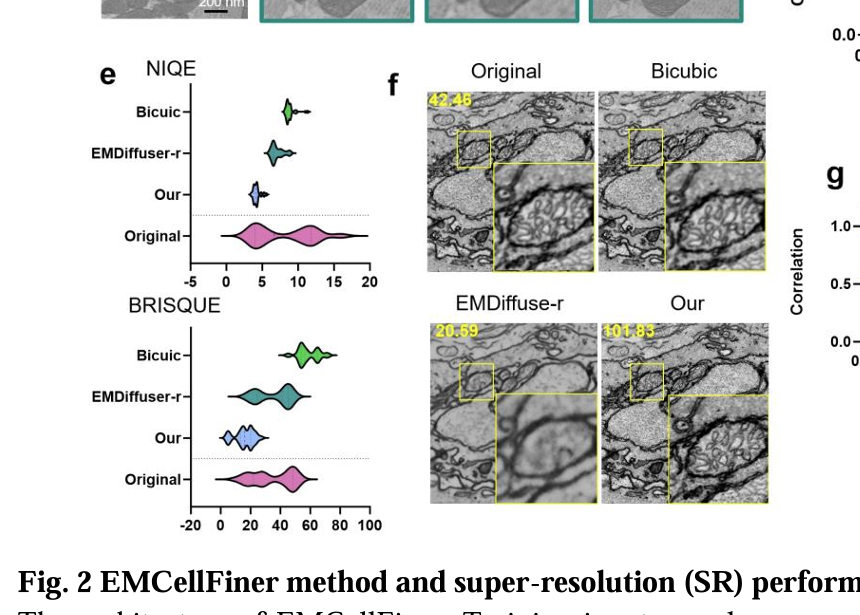

In [ ]:
import matplotlib.pyplot as plt
img1 = Image.open(os.path.join(GT_dir, "MerkelCell0007.tif"))
img2 = Image.open(os.path.join(SR_dir, "MerkelCell0007.tif"))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 16), dpi=300)

# Original Image
im1 = ax1.imshow(img1, cmap="gray")
ax1.set_title("Original EM Image", fontsize=8)
ax1.axis("off")

# Super Resolution Image
im2 = ax2.imshow(img2, cmap="gray")
ax2.set_title("Super-Resolution Image", fontsize=8)
ax2.axis("off")

plt.tight_layout()
plt.show()

## Supplementary Fig. 2

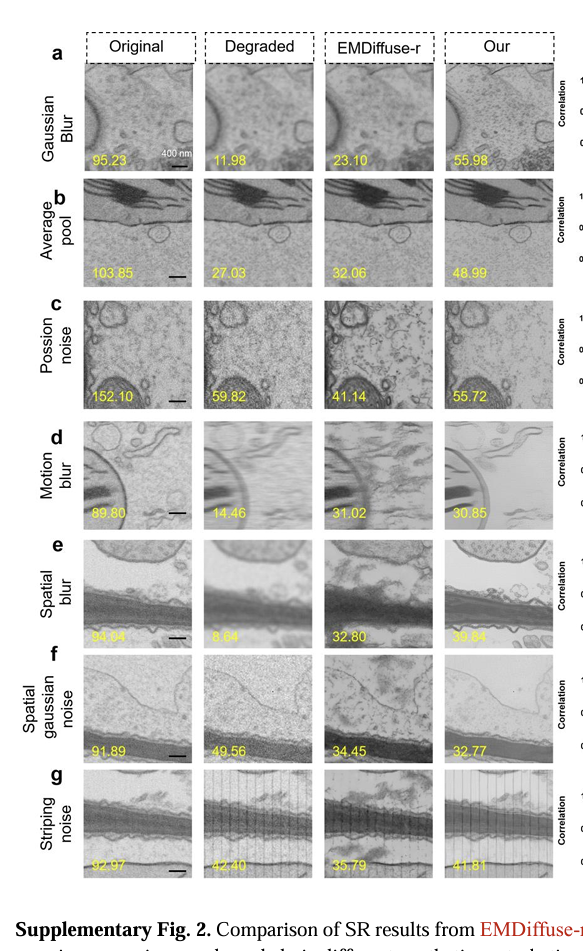

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig2"
)
LR_dir = work_dir / "LR"
SR_dir = work_dir / "SR"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

if not LR_dir.is_dir():
    raise FileNotFoundError(f"LR directory not found: {LR_dir}")
type_dirs = sorted(path for path in LR_dir.iterdir() if path.is_dir())
if not type_dirs:
    raise FileNotFoundError(f"No type directories found in: {LR_dir}")

image_jobs = [
    (image_path, SR_dir / image_path.relative_to(LR_dir))
    for type_dir in type_dirs
    for image_path in sorted(type_dir.rglob("*"))
    if image_path.is_file() and image_path.suffix.lower() in image_suffixes
]
if not image_jobs:
    raise FileNotFoundError(f"No input images found under: {LR_dir}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)
print(f"Device: {device}; types: {len(type_dirs)}; images: {len(image_jobs)}")
print(f"Output directory: {SR_dir}")

with torch.inference_mode():
    for index, (image_path, output_path) in enumerate(image_jobs, start=1):
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with Image.open(image_path) as input_image:
            image = np.array(input_image.convert("RGB"))
        sr_image = hat_infer_numpy(model, image, device=device)
        Image.fromarray(sr_image).save(output_path)
        relative_output = output_path.relative_to(SR_dir)
        print(f"[{index}/{len(image_jobs)}] Saved: {relative_output}")

print(f"Super-resolution completed: {len(image_jobs)} images saved to {SR_dir}")


Visulize FRC curve

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Load the project's bundled FRC implementation (no separate frc checkout needed).
project_root = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Run this cell from the EMCFsys root or demo directory.")
frc_src = project_root / "src" / "thirdParty" / "frc" / "src"
if str(frc_src) not in sys.path:
    sys.path.insert(0, str(frc_src))
try:
    from frc.batch import (
        imread_image, normalized_frequency_axis, prepare_pair, resize_to_reference
    )
    from frc.frc_functions import two_frc
except ModuleNotFoundError as exc:
    raise RuntimeError(
        f"Bundled FRC requires {exc.name!r} in the EMCF_napari environment. "
        "Install the dependencies listed in src/thirdParty/frc/pyproject.toml."
    ) from exc

work_dir = (project_root / "demo" / "datasets_temp"
            / "EMCFsys_SuperResolution_Reproduction_Dataset" / "SR_supFig2")
gt_root = work_dir / "GT"
methods = {"EMDiffuse": work_dir / "EMDiffuse", "SR": work_dir / "SR"}
curve_root = work_dir / "SRC_curve"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}
if not gt_root.is_dir() or any(not root.is_dir() for root in methods.values()):
    raise FileNotFoundError(f"GT, EMDiffuse, and SR directories are required under {work_dir}")

gt_images = sorted(
    path for path in gt_root.rglob("*")
    if path.is_file() and path.suffix.lower() in image_suffixes
)
jobs = [
    (gt_path, gt_path.relative_to(gt_root),
     {label: root / gt_path.relative_to(gt_root)
      for label, root in methods.items()
      if (root / gt_path.relative_to(gt_root)).is_file()})
    for gt_path in gt_images
]
jobs = [job for job in jobs if job[2]]
if not jobs:
    raise FileNotFoundError("No GT images have EMDiffuse or SR counterparts.")
counts = {label: sum(label in paths for _, _, paths in jobs) for label in methods}
print(f"GT: {len(gt_images)}; EMDiffuse pairs: {counts['EMDiffuse']}; "
      f"SR pairs: {counts['SR']}; samples with no prediction: {len(gt_images) - len(jobs)}")

for index, (gt_path, relative_path, prediction_paths) in enumerate(jobs, 1):
    gt = imread_image(gt_path)
    curves = {}
    frequencies = None
    for label, prediction_path in prediction_paths.items():
        prediction = resize_to_reference(imread_image(prediction_path), gt.shape)
        gt_prepared, pred_prepared = prepare_pair(gt, prediction)
        curve = np.asarray(two_frc(gt_prepared, pred_prepared), dtype=np.float64)
        x = normalized_frequency_axis(len(curve), gt_prepared.shape[0])
        if frequencies is not None and not np.array_equal(x, frequencies):
            raise ValueError(f"Inconsistent FRC frequency axes: {relative_path}")
        frequencies = x
        curves[label] = curve

    output_dir = curve_root / relative_path.parent
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    if "EMDiffuse" in curves:
        ax.plot(frequencies, curves["EMDiffuse"], label="EMDiffuse vs GT", color="#4DBBD5")
    if "SR" in curves:
        ax.plot(frequencies, curves["SR"], label="Our SR vs GT", color="#E64B35")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="threshold 0.5")
    ax.set(xlim=(0, 0.5), ylim=(-0.05, 1.05),
           xlabel="Spatial frequency", ylabel="FRC",
           title=f"{relative_path.parent.name}: {relative_path.name}")
    ax.legend(frameon=False)
    fig.savefig(output_dir / f"{relative_path.stem}_FRC.png", dpi=300)
    plt.close(fig)
    np.savetxt(output_dir / f"{relative_path.stem}_FRC.csv",
               np.column_stack((frequencies,
                                curves.get("EMDiffuse", np.full_like(frequencies, np.nan)),
                                curves.get("SR", np.full_like(frequencies, np.nan)))),
               delimiter=",", header="frequency_nyquist,EMDiffuse_vs_GT,SR_vs_GT",
               comments="")
    print(f"[{index}/{len(jobs)}] Saved {relative_path.parent / (relative_path.stem + '_FRC.png')}")

print(f"FRC curves saved to: {curve_root}")


## SupFig4

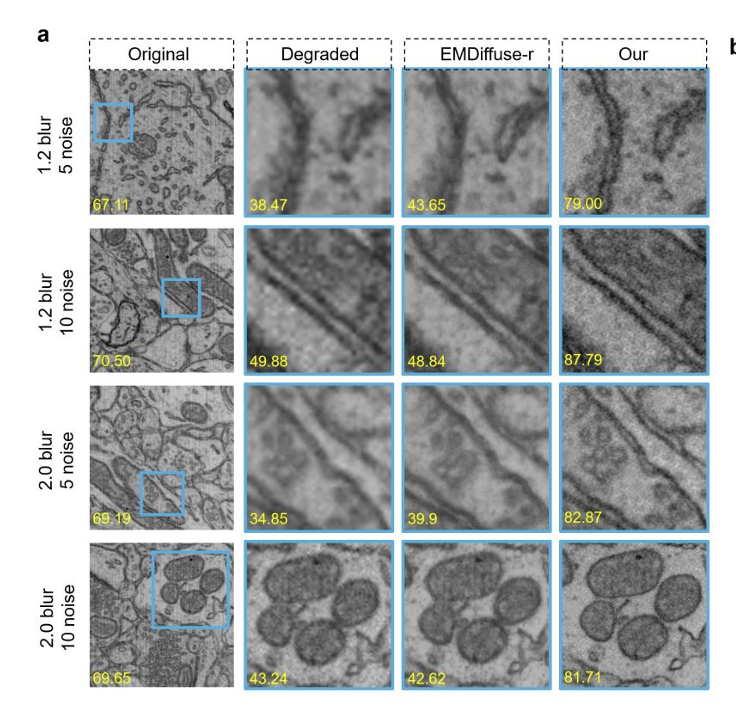

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig4"
)
degraded_root = work_dir / "Degraded"
hr_root = work_dir / "HR"
degrade_classes = (
    "blur1.2_noise5",
    "blur1.2_noise10",
    "blur2.0_noise5",
    "blur2.0_noise10",
)
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

missing_dirs = [name for name in degrade_classes if not (degraded_root / name).is_dir()]
if missing_dirs:
    raise FileNotFoundError(f"Missing degraded data directories: {missing_dirs}")

images_by_class = {
    name: sorted(
        path
        for path in (degraded_root / name).iterdir()
        if path.is_file() and path.suffix.lower() in image_suffixes
    )
    for name in degrade_classes
}
total_images = sum(len(paths) for paths in images_by_class.values())
if total_images == 0:
    raise FileNotFoundError(f"No input images found under {degraded_root}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)
hr_root.mkdir(parents=True, exist_ok=True)
print(f"Device: {device}; images to process: {total_images}")

processed = 0
with torch.inference_mode():
    for class_name, image_paths in images_by_class.items():
        output_dir = hr_root / class_name
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n[{class_name}] {len(image_paths)} images -> {output_dir}")

        for image_path in image_paths:
            with Image.open(image_path) as input_image:
                image = np.array(input_image.convert("RGB"))
            sr_image = hat_infer_numpy(model, image, device=device)
            result_path = output_dir / image_path.name
            Image.fromarray(sr_image).save(result_path)

            processed += 1
            print(f"[{processed}/{total_images}] Saved: {result_path}")

print(f"\nSuper-resolution completed: {processed} images saved under {hr_root}")

## Supplement Fig9

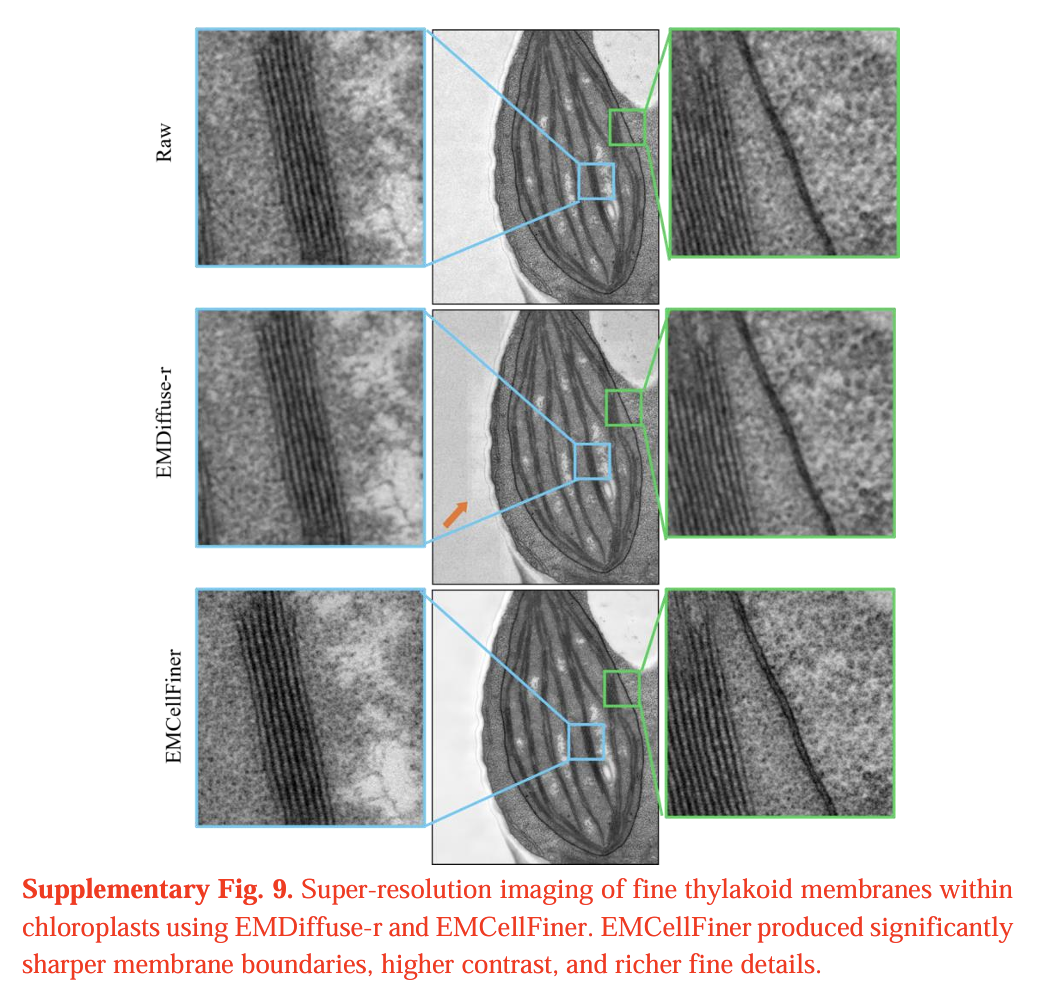

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig9"
)
LR_image_path = (work_dir / "LR.tif")
HR_image_path = (work_dir / "HR.tif")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)

with torch.inference_mode():
    with Image.open(LR_image_path) as input_image:
        image = np.array(input_image.convert("RGB"))
    sr_image = hat_infer_numpy(model, image, device=device)
    Image.fromarray(sr_image).save(HR_image_path)
    print(f"HR image saved: {HR_image_path}")


Then, we can select one ROI for visualization

In [ ]:
# Crop the same square region from LR and HR, then compare them side by side.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
# ROI parameters are expressed in LR pixels. Change these values to inspect another region.
roi_size_lr = 128
roi_center_lr = None  # (x, y); None selects the image center.
save_comparison = True
comparison_path = work_dir / "LR_HR_ROI_comparison.png"

with Image.open(LR_image_path) as lr_source, Image.open(HR_image_path) as hr_source:
    lr_width, lr_height = lr_source.size
    hr_width, hr_height = hr_source.size

    scale_x = hr_width / lr_width
    scale_y = hr_height / lr_height
    if not np.isclose(scale_x, scale_y):
        raise ValueError(f"LR/HR scale mismatch: x={scale_x:.4f}, y={scale_y:.4f}")
    scale = scale_x

    if not 1 <= roi_size_lr <= min(lr_width, lr_height):
        raise ValueError(
            f"roi_size_lr must be between 1 and {min(lr_width, lr_height)}."
        )
    if roi_center_lr is None:
        roi_center_lr = (lr_width // 2 +60, lr_height // 2+60)

    center_x, center_y = map(int, roi_center_lr)
    left = center_x - roi_size_lr // 2
    top = center_y - roi_size_lr // 2
    right = left + roi_size_lr
    bottom = top + roi_size_lr
    if left < 0 or top < 0 or right > lr_width or bottom > lr_height:
        raise ValueError(
            f"LR ROI {(left, top, right, bottom)} exceeds image size "
            f"{(lr_width, lr_height)}. Adjust roi_center_lr or roi_size_lr."
        )

    lr_box = (left, top, right, bottom)
    hr_box = tuple(round(value * scale) for value in lr_box)
    lr_crop = lr_source.convert("L").crop(lr_box)
    hr_crop = hr_source.convert("L").crop(hr_box)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(lr_crop, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title(f"LR ROI ({lr_crop.width} x {lr_crop.height} px)")
axes[1].imshow(hr_crop, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[1].set_title(f"Super-Resolution ROI ({hr_crop.width} x {hr_crop.height} px, {scale:g}x)")
for axis in axes:
    axis.axis("off")

if save_comparison:
    fig.savefig(comparison_path, dpi=300, bbox_inches="tight")
    print(f"Comparison saved: {comparison_path}")
print(f"LR ROI: {lr_box}; HR ROI: {hr_box}")
plt.show()

## SupFig10

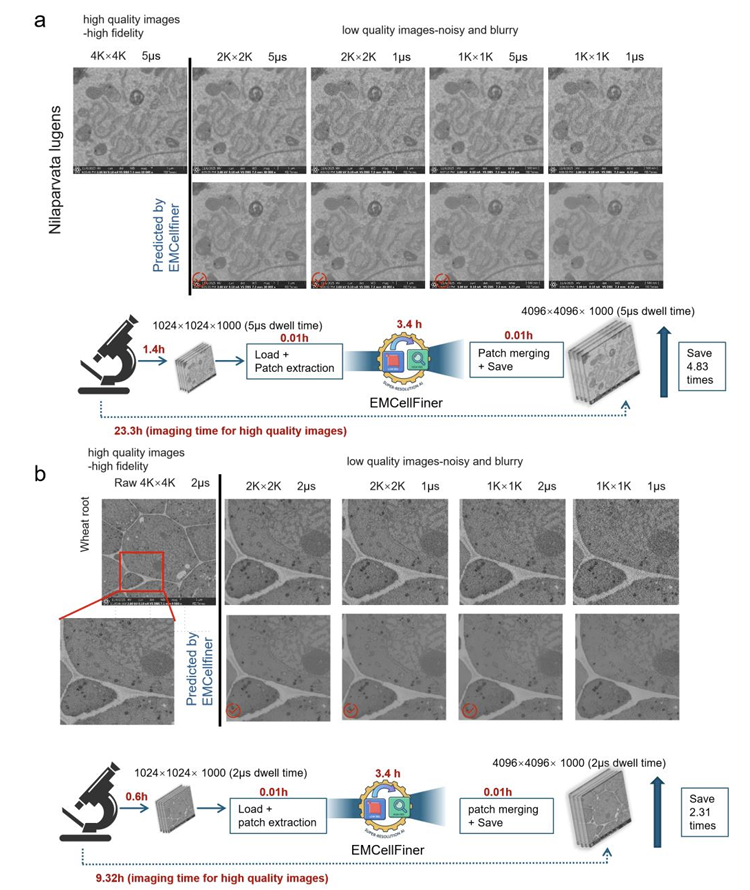

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig10"
    / "SupFig10A"
)
LR_dir = work_dir / "LR"
SR_dir = work_dir / "SR"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

if not LR_dir.is_dir():
    raise FileNotFoundError(f"LR directory not found: {LR_dir}")
image_paths = sorted(
    path
    for path in LR_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_suffixes
)
if not image_paths:
    raise FileNotFoundError(f"No input images found in: {LR_dir}")
SR_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)
print(f"Device: {device}; images to process: {len(image_paths)}")
print(f"Output directory: {SR_dir}")

with torch.inference_mode():
    for index, image_path in enumerate(image_paths, start=1):
        with Image.open(image_path) as input_image:
            H, W = input_image.size
            image = np.array(input_image.resize([H//4, W//4]).convert("RGB"))
        sr_image = hat_infer_numpy(model, image, device=device)
        output_path = SR_dir / image_path.name
        Image.fromarray(sr_image).save(output_path)
        print(f"[{index}/{len(image_paths)}] Saved: {output_path}")

print(f"Super-resolution completed: {len(image_paths)} images saved to {SR_dir}")


In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig10"
    / "SupFig10B"
)
LR_dir = work_dir / "LR"
SR_dir = work_dir / "SR"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

if not LR_dir.is_dir():
    raise FileNotFoundError(f"LR directory not found: {LR_dir}")
image_paths = sorted(
    path
    for path in LR_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_suffixes
)
if not image_paths:
    raise FileNotFoundError(f"No input images found in: {LR_dir}")
SR_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)
print(f"Device: {device}; images to process: {len(image_paths)}")
print(f"Output directory: {SR_dir}")

with torch.inference_mode():
    for index, image_path in enumerate(image_paths, start=1):
        with Image.open(image_path) as input_image:
            H, W = input_image.size
            image = np.array(input_image.resize([H//2, W//2]).convert("RGB"))
        sr_image = hat_infer_numpy(model, image, device=device)
        output_path = SR_dir / image_path.name
        Image.fromarray(sr_image).save(output_path)
        print(f"[{index}/{len(image_paths)}] Saved: {output_path}")

print(f"Super-resolution completed: {len(image_paths)} images saved to {SR_dir}")


## SupFig6

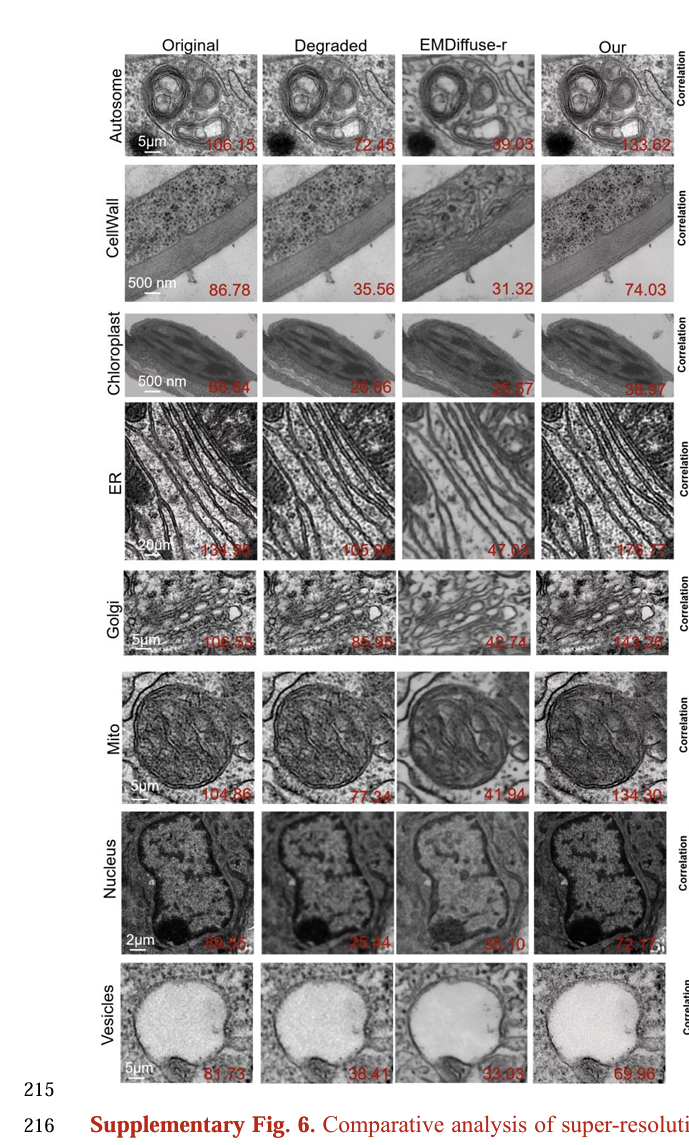

In [ ]:
from pathlib import Path
import sys

import numpy as np
import torch
from PIL import Image

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
print(f"Project root: {project_root}")

from emcfsys.EMCellFiner.hat.models.hat_model import HATModel
from emcfsys.EMCellFiner.hat.models.inference_hat import hat_infer_numpy

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig6"
)
LR_dir = work_dir / "LR"
SR_dir = work_dir / "SR"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

if not LR_dir.is_dir():
    raise FileNotFoundError(f"LR directory not found: {LR_dir}")
type_dirs = sorted(path for path in LR_dir.iterdir() if path.is_dir())
if not type_dirs:
    raise FileNotFoundError(f"No type directories found in: {LR_dir}")

image_jobs = [
    (image_path, SR_dir / image_path.relative_to(LR_dir))
    for type_dir in type_dirs
    for image_path in sorted(type_dir.rglob("*"))
    if image_path.is_file() and image_path.suffix.lower() in image_suffixes
]
if not image_jobs:
    raise FileNotFoundError(f"No input images found under: {LR_dir}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HATModel(scale=4, tile_size=512)
print(f"Device: {device}; types: {len(type_dirs)}; images: {len(image_jobs)}")
print(f"Output directory: {SR_dir}")

with torch.inference_mode():
    for index, (image_path, output_path) in enumerate(image_jobs, start=1):
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with Image.open(image_path) as input_image:
            image = np.array(input_image.convert("RGB"))
        sr_image = hat_infer_numpy(model, image, device=device)
        Image.fromarray(sr_image).save(output_path)
        relative_output = output_path.relative_to(SR_dir)
        print(f"[{index}/{len(image_jobs)}] Saved: {relative_output}")

print(f"Super-resolution completed: {len(image_jobs)} images saved to {SR_dir}")


Show the image from LR ---(by EMCellFiner)---> SR; and SR vs GT

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
# Select one matching LR/GT/SR sample. Set sample_name=None to use the first match.
sample_type_list = ["Autosome", "CellWall", "Chloroplast", "ER",
                    "Golgi", "Mito", "Nucleus", "Vesicles"]
print(f"Random select organelle types from sample_type_list")
sample_type = sample_type_list[random.randint(0, len(sample_type_list))] #"Autosome"
sample_name = None
save_figure = False

# Locate the repository whether Jupyter starts in the project root or demo/.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "src" / "emcfsys").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")

work_dir = (
    project_root
    / "demo"
    / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset"
    / "SR_supFig6"
)
LR_dir = work_dir / "LR" / sample_type
GT_dir = work_dir / "GT" / sample_type
SR_dir = work_dir / "SR" / sample_type
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}

for directory in (LR_dir, GT_dir, SR_dir):
    if not directory.is_dir():
        raise FileNotFoundError(f"Directory not found: {directory}")

common_names = sorted(
    path.name
    for path in LR_dir.iterdir()
    if (
        path.is_file()
        and path.suffix.lower() in image_suffixes
        and (GT_dir / path.name).is_file()
        and (SR_dir / path.name).is_file()
    )
)

print(f"Show SR image random selected from {len(common_names)} results\n")
seed = random.randint(0,len(common_names))

if not common_names:
    raise FileNotFoundError(f"No matching LR/GT/SR images found for type: {sample_type}")
if sample_name is None:
    sample_name = common_names[seed]
elif sample_name not in common_names:
    raise FileNotFoundError(
        f"{sample_name!r} is not present in LR, GT, and SR for type {sample_type!r}."
    )

images = []
for label, directory in (("LR", LR_dir), ("GT", GT_dir), ("SR", SR_dir)):
    with Image.open(directory / sample_name) as image_file:
        image = np.array(image_file.convert("RGB"))
    images.append((label, image))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for axis, (label, image) in zip(axes, images):
    axis.imshow(image, interpolation="nearest")
    axis.set_title(f"{label} ({image.shape[1]} x {image.shape[0]} px)")
    axis.axis("off")
fig.suptitle(f"{sample_type} | {sample_name}", fontsize=14)

if save_figure:
    comparison_path = work_dir / f"{sample_type}_{Path(sample_name).stem}_LR_GT_SR.png"
    fig.savefig(comparison_path, dpi=300, bbox_inches="tight")
    print(f"Comparison saved: {comparison_path}")
    
print(f"Displayed: LR -> SR , vs GT , image name = {sample_type}/{sample_name}")
plt.show()


Generate FRC curves

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Load the project's bundled FRC implementation (no separate frc checkout needed).
project_root = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Run this cell from the EMCFsys root or demo directory.")
frc_src = project_root / "src" / "thirdParty" / "frc" / "src"
if str(frc_src) not in sys.path:
    sys.path.insert(0, str(frc_src))
try:
    from frc.batch import (
        imread_image, normalized_frequency_axis, prepare_pair, resize_to_reference
    )
    from frc.frc_functions import two_frc
except ModuleNotFoundError as exc:
    raise RuntimeError(
        f"Bundled FRC requires {exc.name!r} in the EMCF_napari environment. "
        "Install the dependencies listed in src/thirdParty/frc/pyproject.toml."
    ) from exc

work_dir = (project_root / "demo" / "datasets_temp"
            / "EMCFsys_SuperResolution_Reproduction_Dataset" / "SR_supFig6")
gt_root = work_dir / "GT"
methods = {"EMDiffuse": work_dir / "EMDiffuse", "SR": work_dir / "SR"}
curve_root = work_dir / "SRC_curve"
image_suffixes = {".tif", ".tiff", ".png", ".jpg", ".jpeg"}
if not gt_root.is_dir() or any(not root.is_dir() for root in methods.values()):
    raise FileNotFoundError(f"GT, EMDiffuse, and SR directories are required under {work_dir}")

gt_images = sorted(
    path for path in gt_root.rglob("*")
    if path.is_file() and path.suffix.lower() in image_suffixes
)
jobs = [
    (gt_path, gt_path.relative_to(gt_root),
     {label: root / gt_path.relative_to(gt_root)
      for label, root in methods.items()
      if (root / gt_path.relative_to(gt_root)).is_file()})
    for gt_path in gt_images
]
jobs = [job for job in jobs if job[2]]
if not jobs:
    raise FileNotFoundError("No GT images have EMDiffuse or SR counterparts.")
counts = {label: sum(label in paths for _, _, paths in jobs) for label in methods}
print(f"GT: {len(gt_images)}; EMDiffuse pairs: {counts['EMDiffuse']}; "
      f"SR pairs: {counts['SR']}; samples with no prediction: {len(gt_images) - len(jobs)}")

for index, (gt_path, relative_path, prediction_paths) in enumerate(jobs, 1):
    gt = imread_image(gt_path)
    curves = {}
    frequencies = None
    for label, prediction_path in prediction_paths.items():
        prediction = resize_to_reference(imread_image(prediction_path), gt.shape)
        gt_prepared, pred_prepared = prepare_pair(gt, prediction)
        curve = np.asarray(two_frc(gt_prepared, pred_prepared), dtype=np.float64)
        x = normalized_frequency_axis(len(curve), gt_prepared.shape[0])
        if frequencies is not None and not np.array_equal(x, frequencies):
            raise ValueError(f"Inconsistent FRC frequency axes: {relative_path}")
        frequencies = x
        curves[label] = curve

    output_dir = curve_root / relative_path.parent
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    if "EMDiffuse" in curves:
        ax.plot(frequencies, curves["EMDiffuse"], label="EMDiffuse vs GT", color="#4DBBD5")
    if "SR" in curves:
        ax.plot(frequencies, curves["SR"], label="Our SR vs GT", color="#E64B35")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="threshold 0.5")
    ax.set(xlim=(0, 1.), ylim=(-0.05, 1.05),
           xlabel="Spatial frequency", ylabel="FRC",
           title=f"{relative_path.parent.name}: {relative_path.name}")
    ax.legend(frameon=False)
    fig.savefig(output_dir / f"{relative_path.stem}_FRC.png", dpi=300)
    plt.close(fig)
    np.savetxt(output_dir / f"{relative_path.stem}_FRC.csv",
               np.column_stack((frequencies,
                                curves.get("EMDiffuse", np.full_like(frequencies, np.nan)),
                                curves.get("SR", np.full_like(frequencies, np.nan)))),
               delimiter=",", header="frequency_nyquist,EMDiffuse_vs_GT,SR_vs_GT",
               comments="")
    print(f"[{index}/{len(jobs)}] Saved {relative_path.parent / (relative_path.stem + '_FRC.png')}")

print(f"FRC curves saved to: {curve_root}")


## Generate All FRC curves as Paper shows

In [ ]:
from pathlib import Path
import sys

# Find the repository root from either the project root or demo/ directory.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
frc_source = project_root / "src" / "thirdParty" / "frc" / "src"
if str(frc_source) not in sys.path:
    sys.path.insert(0, str(frc_source))

from frc.batch import (
    DEFAULT_SMOOTH_WINDOW, DEFAULT_SQUARE_MODE, DEFAULT_SUBTRACT_MEAN,
    DEFAULT_WINDOW_ALPHA, find_numbered_image, process_one_folder,
)

frc_root = (
    project_root / "demo" / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset" / "FRC_curve"
)
if not frc_root.is_dir():
    raise FileNotFoundError(f"FRC input directory not found: {frc_root}")

# Each sample folder contains reference 1 and at least one result 2, 3, or 4.
sample_dirs = [
    folder for folder in frc_root.rglob("*")
    if folder.is_dir()
    and find_numbered_image(folder, "1")[0] is not None
    and any(find_numbered_image(folder, number)[0] is not None
            for number in ("2", "3", "4"))
]
sample_dirs.sort(key=lambda folder: folder.relative_to(frc_root).as_posix().lower())
if not sample_dirs:
    raise FileNotFoundError(f"No numbered FRC sample folders found under {frc_root}")

print(f"Calculating FRC curves for {len(sample_dirs)} folders under {frc_root}")
failures = []
for index, folder in enumerate(sample_dirs, start=1):
    relative_folder = folder.relative_to(frc_root)
    print(f"[{index}/{len(sample_dirs)}] {relative_folder}")
    try:
        _, curves, warnings = process_one_folder(
            folder, frc_root, frc_root,
            smooth_window=DEFAULT_SMOOTH_WINDOW,
            square_mode=DEFAULT_SQUARE_MODE,
            subtract_mean=DEFAULT_SUBTRACT_MEAN,
            apply_window=True,
            window_alpha=DEFAULT_WINDOW_ALPHA,
            make_plots=True,
        )
        print(f"  Saved {len(curves)} curves in {folder}")
        for warning in warnings:
            print(f"  Warning: {warning}")
    except Exception as exc:
        failures.append((relative_folder, str(exc)))
        print(f"  Failed: {exc}")

if failures:
    details = "; ".join(f"{folder}: {error}" for folder, error in failures)
    raise RuntimeError(f"FRC failed for {len(failures)} folders: {details}")
print(f"Done: FRC figures and CSV files saved in all {len(sample_dirs)} sample folders.")


## Generate FID\FSIM\PSNR from images

In [ ]:
from pathlib import Path
import csv
import importlib
import statistics
import sys

import torch

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
metrics_module = importlib.import_module("emcfsys.EMCellFiner.hat.utils.eval")
metrics_module = importlib.reload(metrics_module)

work_dir = (
    project_root / "demo" / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset" / "SR_Fig2C"
)
gt_dir = work_dir / "GT"
sr_dir = work_dir / "SR"
if not gt_dir.is_dir() or not sr_dir.is_dir():
    raise FileNotFoundError(f"Expected GT and SR folders under {work_dir}")
image_suffixes = {".png", ".tif", ".tiff"}
gt_images = {p.name: p for p in gt_dir.iterdir()
             if p.is_file() and p.suffix.lower() in image_suffixes}
sr_images = sorted(p for p in sr_dir.iterdir()
                   if p.is_file() and p.suffix.lower() in image_suffixes)
pairs = [(gt_images[p.name], p) for p in sr_images if p.name in gt_images]
if not pairs:
    raise FileNotFoundError("No SR images have a same-name GT counterpart.")
print(f"Evaluating {len(pairs)} SR/GT pairs with the updated eval.py")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metric_size = (512, 512)
rows = []
for index, (gt_path, sr_path) in enumerate(pairs, start=1):
    rows.append({
        "Image": sr_path.name,
        "PSNR_dB": metrics_module.psnr(gt_path, sr_path, size=None),
        "FSIM": metrics_module.fsim(gt_path, sr_path, size=metric_size, device=device),
        "FID": metrics_module.fid(gt_path, sr_path, device=device),
    })
    if index == 1 or index % 10 == 0 or index == len(pairs):
        print(f"[{index}/{len(pairs)}] {sr_path.name}")

output_csv = work_dir / "SR_vs_GT_metrics_manual_folders.csv"
fieldnames = ("Image", "PSNR_dB", "FSIM", "FID")
with output_csv.open("w", newline="", encoding="utf-8-sig") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Mean over paired images:")
for label in fieldnames[1:]:
    print(f"  {label}: {statistics.fmean(row[label] for row in rows):.4f}")
print(f"Saved: {output_csv}")


FileNotFoundError: No SR images have a same-name GT counterpart.

#### for sup fig4

In [ ]:
from pathlib import Path
import csv
import importlib
import statistics
import sys

import torch

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
metrics_module = importlib.import_module("emcfsys.EMCellFiner.hat.utils.eval")
metrics_module = importlib.reload(metrics_module)

work_dir = (
    project_root / "demo" / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset" / "SR_Fig2C"
)
gt_dir = work_dir / "GT"
sr_dir = work_dir / "SR"
if not gt_dir.is_dir() or not sr_dir.is_dir():
    raise FileNotFoundError(f"Expected GT and SR folders under {work_dir}")
image_suffixes = {".png", ".tif", ".tiff"}
gt_images = {p.name: p for p in gt_dir.iterdir()
             if p.is_file() and p.suffix.lower() in image_suffixes}
sr_images = sorted(p for p in sr_dir.iterdir()
                   if p.is_file() and p.suffix.lower() in image_suffixes)
pairs = [(gt_images[p.name], p) for p in sr_images if p.name in gt_images]
if not pairs:
    raise FileNotFoundError("No SR images have a same-name GT counterpart.")
print(f"Evaluating {len(pairs)} SR/GT pairs with the updated eval.py")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metric_size = (512, 512)
rows = []
for index, (gt_path, sr_path) in enumerate(pairs, start=1):
    rows.append({
        "Image": sr_path.name,
        "PSNR_dB": metrics_module.psnr(gt_path, sr_path, size=None),
        "FSIM": metrics_module.fsim(gt_path, sr_path, size=metric_size, device=device),
        "FID": metrics_module.fid(gt_path, sr_path, device=device),
    })
    if index == 1 or index % 10 == 0 or index == len(pairs):
        print(f"[{index}/{len(pairs)}] {sr_path.name}")

output_csv = work_dir / "SR_vs_GT_metrics_manual_folders.csv"
fieldnames = ("Image", "PSNR_dB", "FSIM", "FID")
with output_csv.open("w", newline="", encoding="utf-8-sig") as handle:
    writer = csv.DictWriter(handle, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Mean over paired images:")
for label in fieldnames[1:]:
    print(f"  {label}: {statistics.fmean(row[label] for row in rows):.4f}")
print(f"Saved: {output_csv}")


In [ ]:
from pathlib import Path
from collections import defaultdict
import csv
import importlib
import statistics
import sys

import torch

# Evaluate every SR_supFig4 degradation: degraded input and SR result vs GT.
current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "demo" / "SR.ipynb").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the EMCFsys project root.")
src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
metrics_module = importlib.import_module("emcfsys.EMCellFiner.hat.utils.eval")
metrics_module = importlib.reload(metrics_module)

work_dir = (
    project_root / "demo" / "datasets_temp"
    / "EMCFsys_SuperResolution_Reproduction_Dataset" / "SR_supFig4"
)
gt_dir = work_dir / "GT"
degraded_root = work_dir / "Degraded"
sr_root = work_dir / "HR"
degradation_names = (
    "blur1.2_noise5", "blur1.2_noise10",
    "blur2.0_noise5", "blur2.0_noise10",
)
image_suffixes = {".png", ".tif", ".tiff", ".jpg", ".jpeg"}
for directory in (gt_dir, degraded_root, sr_root):
    if not directory.is_dir():
        raise FileNotFoundError(f"Required directory not found: {directory}")

gt_images = {path.name: path for path in gt_dir.iterdir()
             if path.is_file() and path.suffix.lower() in image_suffixes}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metric_size = (512, 512)
rows = []
total = len(degradation_names) * len(gt_images) * 2
processed = 0

for degradation in degradation_names:
    method_dirs = {
        "Degraded": degraded_root / degradation,
        "SR": sr_root / degradation,
    }
    for directory in method_dirs.values():
        if not directory.is_dir():
            raise FileNotFoundError(f"Treatment directory not found: {directory}")
    common_names = sorted(
        name for name in gt_images
        if all((directory / name).is_file() for directory in method_dirs.values())
    )
    if not common_names:
        raise FileNotFoundError(f"No paired images for {degradation}")
    if len(common_names) != len(gt_images):
        print(f"Warning: {degradation} has {len(common_names)}/{len(gt_images)} complete pairs")

    for image_name in common_names:
        gt_path = gt_images[image_name]
        gt_sharpness = metrics_module.sharpness(gt_path, size=metric_size)
        for method, directory in method_dirs.items():
            prediction_path = directory / image_name
            rows.append({
                "Degradation": degradation,
                "Method": method,
                "Image": image_name,
                "PSNR_dB": metrics_module.psnr(gt_path, prediction_path, size=metric_size),
                "FSIM": metrics_module.fsim(gt_path, prediction_path,
                                            size=metric_size, device=device),
                "FID": metrics_module.fid(gt_path, prediction_path, device=device),
                "Sharpness": metrics_module.sharpness(prediction_path, size=metric_size),
                "GT_Sharpness": gt_sharpness,
            })
            processed += 1
            if processed == 1 or processed % 25 == 0 or processed == total:
                print(f"[{processed}/{total}] {degradation} | {method} | {image_name}")

detail_csv = work_dir / "SR_supFig4_metrics_by_image.csv"
detail_fields = (
    "Degradation", "Method", "Image", "PSNR_dB", "FSIM", "FID",
    "Sharpness", "GT_Sharpness",
)
with detail_csv.open("w", newline="", encoding="utf-8-sig") as handle:
    writer = csv.DictWriter(handle, fieldnames=detail_fields)
    writer.writeheader()
    writer.writerows(rows)

groups = defaultdict(list)
for row in rows:
    groups[(row["Degradation"], row["Method"])].append(row)
summary_rows = []
metric_columns = ("PSNR_dB", "FSIM", "FID", "Sharpness", "GT_Sharpness")
for (degradation, method), group in sorted(groups.items()):
    summary = {"Degradation": degradation, "Method": method, "Count": len(group)}
    for metric in metric_columns:
        values = [float(row[metric]) for row in group]
        summary[f"{metric}_Mean"] = statistics.fmean(values)
        summary[f"{metric}_Std"] = statistics.stdev(values) if len(values) > 1 else 0.0
    summary_rows.append(summary)

summary_csv = work_dir / "SR_supFig4_metrics_summary.csv"
summary_fields = tuple(summary_rows[0])
with summary_csv.open("w", newline="", encoding="utf-8-sig") as handle:
    writer = csv.DictWriter(handle, fieldnames=summary_fields)
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nSummary (mean):")
for row in summary_rows:
    print(f"{row['Degradation']:18s} {row['Method']:8s} n={row['Count']:3d} | "
          f"PSNR={row['PSNR_dB_Mean']:.3f} dB | FSIM={row['FSIM_Mean']:.4f} | "
          f"FID={row['FID_Mean']:.4f} | Sharpness={row['Sharpness_Mean']:.3f}")
print(f"\nPer-image metrics: {detail_csv}")
print(f"Summary metrics: {summary_csv}")


[1/800] blur1.2_noise5 | Degraded | jrc_mus-nacc-20009_crop.tif
[25/800] blur1.2_noise5 | Degraded | jrc_mus-nacc-20066_crop.tif
[50/800] blur1.2_noise5 | SR | jrc_mus-nacc-20123_crop.tif
[75/800] blur1.2_noise5 | Degraded | jrc_mus-nacc-20180_crop.tif
[100/800] blur1.2_noise5 | SR | jrc_mus-nacc-20257_crop.tif
[125/800] blur1.2_noise5 | Degraded | jrc_mus-nacc-20343_crop.tif
[150/800] blur1.2_noise5 | SR | jrc_mus-nacc-20402_crop.tif
[175/800] blur1.2_noise5 | Degraded | jrc_mus-nacc-20455_crop.tif
[200/800] blur1.2_noise5 | SR | jrc_mus-nacc-20560_crop.tif
[225/800] blur1.2_noise10 | Degraded | jrc_mus-nacc-20066_crop.tif
[250/800] blur1.2_noise10 | SR | jrc_mus-nacc-20123_crop.tif
[275/800] blur1.2_noise10 | Degraded | jrc_mus-nacc-20180_crop.tif
[300/800] blur1.2_noise10 | SR | jrc_mus-nacc-20257_crop.tif
[325/800] blur1.2_noise10 | Degraded | jrc_mus-nacc-20343_crop.tif
[350/800] blur1.2_noise10 | SR | jrc_mus-nacc-20402_crop.tif
[375/800] blur1.2_noise10 | Degraded | jrc_mus-nacc